In [1]:
# 1) Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 2) Load Spotify Dataset
spotify_df = pd.read_csv("../data/spotify_data.csv")

In [8]:
# 3) Initial Dataset Overview
spotify_df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cover_url
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,B,Major,80,89,83,31,0,8,4,Not Found
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,C#,Major,71,61,74,7,0,10,4,https://i.scdn.co/image/ab67616d0000b2730656d5...
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,F,Major,51,32,53,17,0,31,6,https://i.scdn.co/image/ab67616d0000b273e85259...
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,A,Major,55,58,72,11,0,11,15,https://i.scdn.co/image/ab67616d0000b273e787cf...
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,A,Minor,65,23,80,14,63,11,6,https://i.scdn.co/image/ab67616d0000b273ab5c9c...


In [9]:
spotify_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   track_name            953 non-null    str  
 1   artist(s)_name        953 non-null    str  
 2   artist_count          953 non-null    int64
 3   released_year         953 non-null    int64
 4   released_month        953 non-null    int64
 5   released_day          953 non-null    int64
 6   in_spotify_playlists  953 non-null    int64
 7   in_spotify_charts     953 non-null    int64
 8   streams               953 non-null    str  
 9   in_apple_playlists    953 non-null    int64
 10  in_apple_charts       953 non-null    int64
 11  in_deezer_playlists   953 non-null    str  
 12  in_deezer_charts      953 non-null    int64
 13  in_shazam_charts      903 non-null    str  
 14  bpm                   953 non-null    int64
 15  key                   858 non-null    str  
 16  mode               

In [12]:
# 4) Remove Rows with Null Values
spotify_df_clean = spotify_df.dropna()

In [13]:
# 5) Remove Duplicate Songs 
# track_name + artist(s)_name
spotify_df_clean = spotify_df_clean.drop_duplicates(
    subset=["track_name","artist(s)_name"],
    keep="first"
)

In [14]:
# 6) Fix Streams Column
spotify_df_clean["streams"] = spotify_df_clean["streams"].astype(str)
spotify_df_clean["streams"] = spotify_df_clean["streams"].str.replace(",", "", regex=False)

spotify_df_clean["streams"] = pd.to_numeric(
    spotify_df_clean["streams"],
    errors="coerce"
)

spotify_df_clean = spotify_df_clean.dropna(subset=["streams"])
spotify_df_clean["streams"] = spotify_df_clean["streams"].astype(int)

In [15]:
# 7) Verify Cleaned Dataset
spotify_df_clean.info()

<class 'pandas.DataFrame'>
Index: 813 entries, 0 to 952
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   track_name            813 non-null    str  
 1   artist(s)_name        813 non-null    str  
 2   artist_count          813 non-null    int64
 3   released_year         813 non-null    int64
 4   released_month        813 non-null    int64
 5   released_day          813 non-null    int64
 6   in_spotify_playlists  813 non-null    int64
 7   in_spotify_charts     813 non-null    int64
 8   streams               813 non-null    int64
 9   in_apple_playlists    813 non-null    int64
 10  in_apple_charts       813 non-null    int64
 11  in_deezer_playlists   813 non-null    str  
 12  in_deezer_charts      813 non-null    int64
 13  in_shazam_charts      813 non-null    str  
 14  bpm                   813 non-null    int64
 15  key                   813 non-null    str  
 16  mode                  81

In [16]:
# 8) Top 10 Most Listened Songs
top_songs = spotify_df_clean.sort_values(
    by="streams",
    ascending=False
).head(10)

top_songs[["track_name", "artist(s)_name", "streams"]]

,track_name,artist(s)_name,streams
179,Shape of You,Ed Sheeran,3562543890
41,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",2808096550
162,One Dance,"Drake, WizKid, Kyla",2713922350
84,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi",2665343922
140,Believer,Imagine Dragons,2594040133
725,Closer,"The Chainsmokers, Halsey",2591224264
48,Starboy,"The Weeknd, Daft Punk",2565529693
138,Perfect,Ed Sheeran,2559529074
693,Seï¿½ï¿½o,"Shawn Mendes, Camila Cabello",2484812918
324,Say You Won't Let Go,James Arthur,2420461338


In [17]:
# 9) Top Artists by Total Streams
top_artists = (
    spotify_df_clean
    .groupby("artist(s)_name")["streams"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_artists

artist(s)_name
Taylor Swift       11851151082
Ed Sheeran         11051252012
Bad Bunny           8582384095
Eminem              6183805596
Harry Styles        6033490512
The Weeknd          5605938420
Imagine Dragons     5272484650
Adele               4508746590
SZA                 4197341485
Bruno Mars          4185733280
Name: streams, dtype: int64

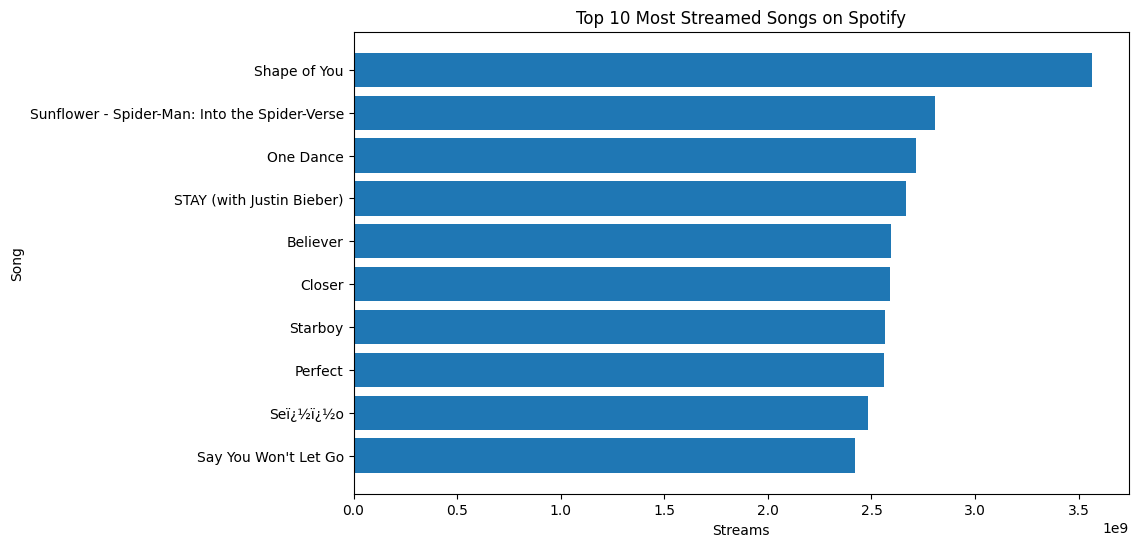

In [18]:
# 10) Visualization - Top 10 Songs
plt.figure(figsize=(10, 6))
plt.barh(
    top_songs["track_name"],
    top_songs["streams"]
)
plt.xlabel("Streams")
plt.ylabel("Song")
plt.title("Top 10 Most Streamed Songs on Spotify")
plt.gca().invert_yaxis()
plt.show()

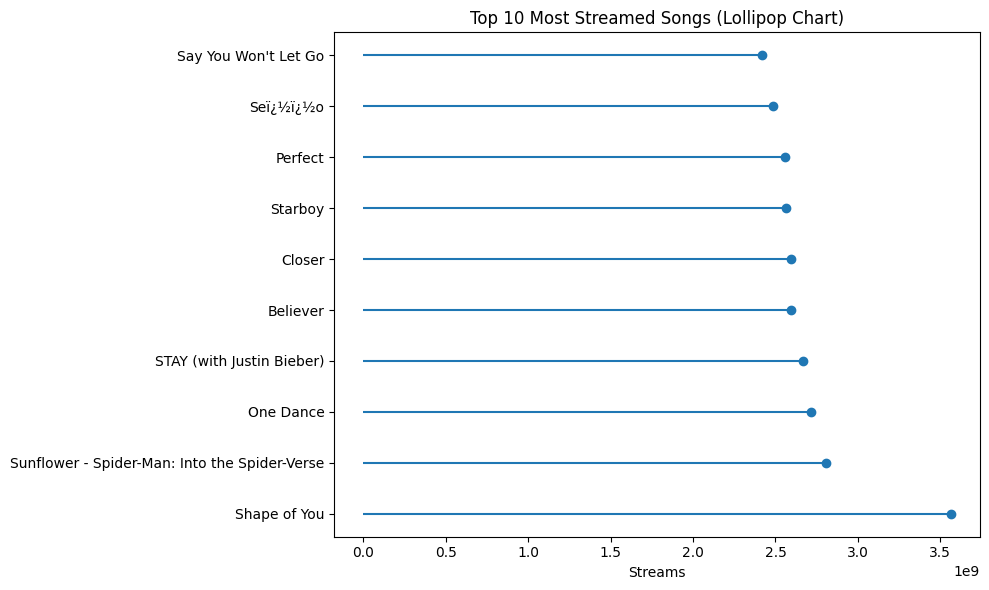

In [23]:
# 11) Visualization - Top Artists
plt.figure(figsize=(10, 6))
plt.hlines(
    y=top_songs["track_name"],
    xmin=0,
    xmax=top_songs["streams"]
)
plt.plot(
    top_songs["streams"],
    top_songs["track_name"],
    "o"
)
plt.xlabel("Streams")
plt.title("Top 10 Most Streamed Songs (Lollipop Chart)")
plt.tight_layout()
plt.show()

In [20]:
# 12) Save Cleaned Dataset
spotify_df_clean.to_csv(
    "../analysis/spotify_cleaned_data.csv",
    index=False
)

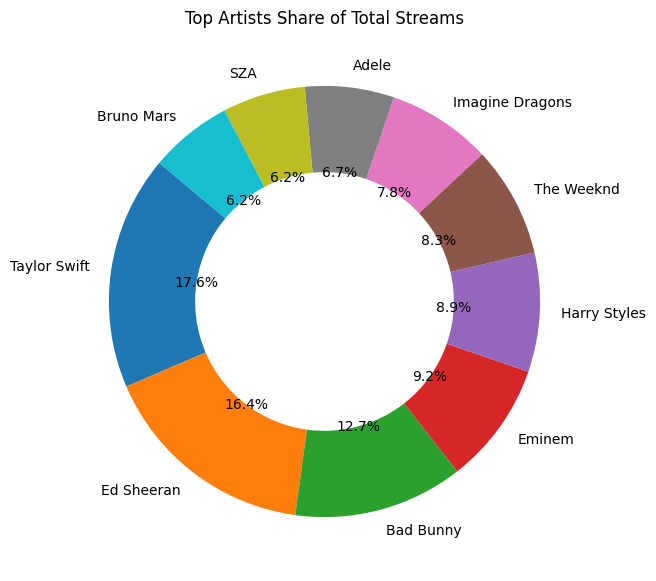

In [21]:
plt.figure(figsize=(7, 7))
plt.pie(
    top_artists,
    labels=top_artists.index,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"width": 0.4}
)
plt.title("Top Artists Share of Total Streams")
plt.show()